# 2D Attention U-Net — KSSD2025


## Cell 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted at /content/drive')

Mounted at /content/drive
Drive mounted at /content/drive


## Cell 2 — Install dependencies

In [3]:
!pip install -q albumentations
import albumentations
print(f'albumentations {albumentations.__version__} ready')

albumentations 2.0.8 ready


## Cell 3 — Configure paths  ⚙️  

In [4]:
import os

# ── Edit these two lines if your folder names differ ──────────────────────
DRIVE_ROOT  = "/content/drive/MyDrive/Kidney_Stone_Segmentation_2"
IMAGE_DIR   = os.path.join(DRIVE_ROOT, 'image')
MASK_DIR    = os.path.join(DRIVE_ROOT, 'label')
# ──────────────────────────────────────────────────────────────────────────

CHECKPOINT_DIR = '/content/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────
IMG_SIZE     = 256
BATCH_SIZE   = 8
EPOCHS       = 50
LR           = 1e-3
TRAIN_SPLIT  = 0.70   # 70% train
VAL_SPLIT    = 0.10   # 10% validation
TEST_SPLIT   = 0.20   # 20% test  
SEED         = 42
# ──────────────────────────────────────────────────────────────────────────

print('IMAGE_DIR :', IMAGE_DIR)
print('MASK_DIR  :', MASK_DIR)
print('Exists?   :', os.path.isdir(IMAGE_DIR), os.path.isdir(MASK_DIR))

IMAGE_DIR : /content/drive/MyDrive/Kidney_Stone_Segmentation_2/image
MASK_DIR  : /content/drive/MyDrive/Kidney_Stone_Segmentation_2/label
Exists?   : True True


## Cell 4 — Verify dataset

Images found : 838
Masks found  : 838


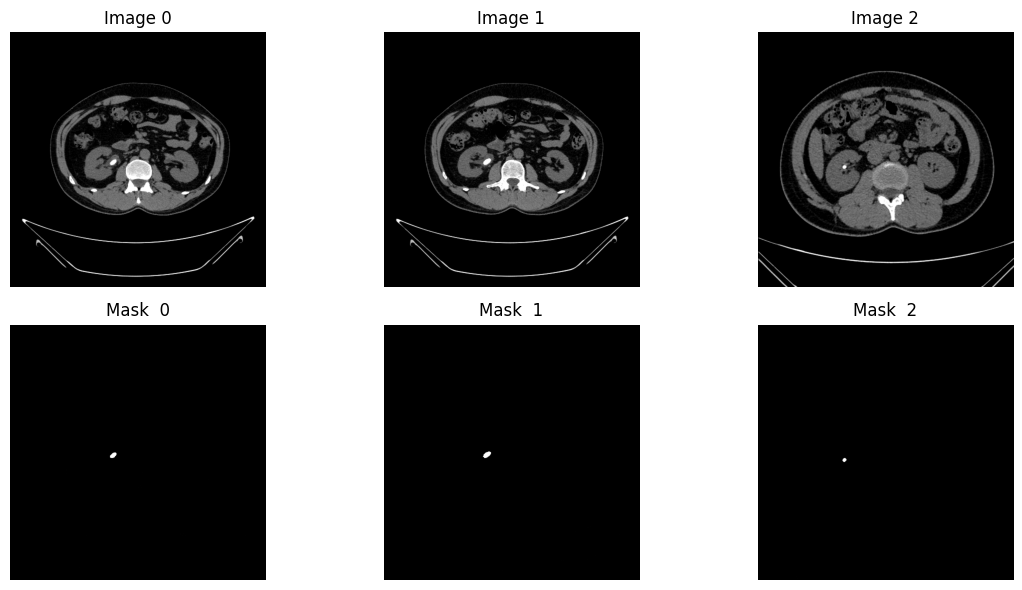

In [5]:
import glob

# Adjust extension if your files are .jpg instead of .png
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.tif')))
mask_paths  = sorted(glob.glob(os.path.join(MASK_DIR,  '*.tif')))

print(f'Images found : {len(image_paths)}')
print(f'Masks found  : {len(mask_paths)}')

assert len(image_paths) > 0,            'No images found — check IMAGE_DIR and file extension'
assert len(image_paths) == len(mask_paths), 'Image / mask count mismatch'

# Quick visual sanity check
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax_row in enumerate(axes.T):
    img  = np.array(Image.open(image_paths[i]).convert('L'))
    mask = np.array(Image.open(mask_paths[i]).convert('L'))
    ax_row[0].imshow(img,  cmap='gray');  ax_row[0].set_title(f'Image {i}')
    ax_row[1].imshow(mask, cmap='gray');  ax_row[1].set_title(f'Mask  {i}')
    for ax in ax_row: ax.axis('off')
plt.tight_layout(); plt.show()

## Cell 5 — Model, losses, dataset, augmentation

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Building blocks ───────────────────────────────────────────────────────

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g,  F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l,  F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1,    1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
    def forward(self, g, x):
        return x * self.psi(F.relu(self.W_g(g) + self.W_x(x), inplace=True))


class AttentionUNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024, dropout_p=0.3)
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att4 = AttentionGate(512, 512, 256)
        self.dec4 = DoubleConv(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att3 = AttentionGate(256, 256, 128)
        self.dec3 = DoubleConv(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att2 = AttentionGate(128, 128, 64)
        self.dec2 = DoubleConv(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionGate(64,  64,  32)
        self.dec1 = DoubleConv(128, 64)
        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.bottleneck(self.pool4(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  self.att4(self.up4(b),  e4)], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), self.att3(self.up3(d4), e3)], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), self.att2(self.up2(d3), e2)], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), self.att1(self.up1(d2), e1)], 1))
        return self.final(d1)

# ── Losses ────────────────────────────────────────────────────────────────

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6): super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1); t = targets.view(-1)
        return 1.0 - (2.0*(p*t).sum()+self.smooth)/(p.sum()+t.sum()+self.smooth)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0): super().__init__(); self.alpha=alpha; self.gamma=gamma
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        return (self.alpha*(1-torch.exp(-bce))**self.gamma*bce).mean()

class FocalDiceLoss(nn.Module):
    def __init__(self, fw=0.4): super().__init__(); self.focal=FocalLoss(); self.dice=DiceLoss(); self.fw=fw
    def forward(self, logits, targets): return self.fw*self.focal(logits,targets)+(1-self.fw)*self.dice(logits,targets)

def dice_score(logits, targets, threshold=0.5, smooth=1e-6):
    p = (torch.sigmoid(logits)>threshold).float().view(-1); t = targets.view(-1)
    return ((2.0*(p*t).sum()+smooth)/(p.sum()+t.sum()+smooth)).item()

# ── Augmentation ──────────────────────────────────────────────────────────

def get_train_tf(sz=256):
    return A.Compose([
        A.Resize(sz, sz),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=20, p=0.5),
        A.ElasticTransform(alpha=120, sigma=6, alpha_affine=3.6, p=0.3),
        A.GridDistortion(p=0.3),
        A.RandomBrightnessContrast(p=0.4),
        A.GaussNoise(var_limit=(5,20), p=0.3),
        A.Normalize(mean=(0.5,), std=(0.5,)),
        ToTensorV2(),
    ])

def get_val_tf(sz=256):
    return A.Compose([A.Resize(sz,sz), A.Normalize(mean=(0.5,),std=(0.5,)), ToTensorV2()])

# ── Dataset ───────────────────────────────────────────────────────────────

class SegDataset(Dataset):
    def __init__(self, imgs, masks, tf=None): self.imgs=imgs; self.masks=masks; self.tf=tf
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        img  = np.array(Image.open(self.imgs[idx]).convert('L'))
        mask = np.array(Image.open(self.masks[idx]).convert('L'))
        if self.tf:
            aug  = self.tf(image=img, mask=mask)
            img  = aug['image'].float()
            mask = aug['mask'].unsqueeze(0).float()/255.0
        else:
            img  = torch.tensor(img).unsqueeze(0).float()/255.0
            mask = torch.tensor(mask).unsqueeze(0).float()/255.0
        return img, (mask>0.5).float()

# ── Early stopping ────────────────────────────────────────────────────────

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience=patience; self.min_delta=min_delta
        self.best=None; self.counter=0; self.stop=False
    def __call__(self, score):
        if self.best is None or score > self.best+self.min_delta:
            self.best=score; self.counter=0
        else:
            self.counter+=1
            if self.counter>=self.patience: self.stop=True

print('All classes defined ✓')

All classes defined ✓


## Cell 6 — Build dataloaders

In [7]:
n_total  = len(image_paths)
n_test   = max(1, int(n_total * TEST_SPLIT))
n_val    = max(1, int(n_total * VAL_SPLIT))
n_train  = n_total - n_val - n_test

rng      = np.random.default_rng(SEED)
idx      = rng.permutation(n_total)
train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train + n_val]
test_idx  = idx[n_train + n_val:]

train_ds = SegDataset([image_paths[i] for i in train_idx], [mask_paths[i] for i in train_idx], get_train_tf(IMG_SIZE))
val_ds   = SegDataset([image_paths[i] for i in val_idx],   [mask_paths[i] for i in val_idx],   get_val_tf(IMG_SIZE))
test_ds  = SegDataset([image_paths[i] for i in test_idx],  [mask_paths[i] for i in test_idx],  get_val_tf(IMG_SIZE))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Total   : {n_total}')
print(f'Train   : {len(train_ds):>4}  ({len(train_ds)/n_total*100:.0f}%)')
print(f'Val     : {len(val_ds):>4}  ({len(val_ds)/n_total*100:.0f}%)')
print(f'Test    : {len(test_ds):>4}  ({len(test_ds)/n_total*100:.0f}%)')

Total   : 838
Train   :  588  (70%)
Val     :   83  (10%)
Test    :  167  (20%)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_2917/4051558784.py:104: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=6, alpha_affine=3.6, p=0.3),
/tmp/ipykernel_2917/4051558784.py:107: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5,20), p=0.3),


## Cell 7 — Training

In [8]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model     = AttentionUNet2D(in_channels=1, out_channels=1).to(device)
criterion = FocalDiceLoss(fw=0.4)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS,
    steps_per_epoch=len(train_loader), pct_start=0.1, anneal_strategy='cos'
)
scaler    = GradScaler()
es        = EarlyStopping(patience=10)

best_dice = 0.0
best_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')

history   = {'loss': [], 'val_dice': []}

for epoch in range(EPOCHS):
    # ── train ──
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with autocast():
            loss = criterion(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        scheduler.step()
        running_loss += loss.item()

    # ── validate ──
    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with autocast():
                logits = model(imgs)
            val_dice += dice_score(logits, masks)

    avg_loss  = running_loss / len(train_loader)
    avg_dice  = val_dice     / len(val_loader)
    history['loss'].append(avg_loss)
    history['val_dice'].append(avg_dice)

    flag = ''
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), best_path)
        flag = '  ← best'

    print(f'Ep {epoch+1:02d}/{EPOCHS}  loss={avg_loss:.4f}  val_dice={avg_dice:.4f}{flag}')

    es(avg_dice)
    if es.stop:
        print('Early stopping triggered.')
        break

print(f'\nBest Val Dice: {best_dice:.4f}  ({best_dice*100:.1f}%)')
print(f'Checkpoint  : {best_path}')

Device: cuda


/tmp/ipykernel_2917/521010782.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_2917/521010782.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_2917/521010782.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 01/50  loss=0.6382  val_dice=0.0000  ← best
Ep 02/50  loss=0.6103  val_dice=0.0000  ← best
Ep 03/50  loss=0.6048  val_dice=0.0000
Ep 04/50  loss=0.6014  val_dice=0.2990  ← best
Ep 05/50  loss=0.5998  val_dice=0.0000
Ep 06/50  loss=0.5984  val_dice=0.1694
Ep 07/50  loss=0.5964  val_dice=0.2324
Ep 08/50  loss=0.5908  val_dice=0.1383
Ep 09/50  loss=0.5505  val_dice=0.4276  ← best
Ep 10/50  loss=0.4625  val_dice=0.1550
Ep 11/50  loss=0.4224  val_dice=0.5908  ← best
Ep 12/50  loss=0.4109  val_dice=0.5358
Ep 13/50  loss=0.3835  val_dice=0.6521  ← best
Ep 14/50  loss=0.3621  val_dice=0.6477
Ep 15/50  loss=0.3551  val_dice=0.7308  ← best
Ep 16/50  loss=0.3374  val_dice=0.8039  ← best
Ep 17/50  loss=0.3296  val_dice=0.7555
Ep 18/50  loss=0.3185  val_dice=0.7921
Ep 19/50  loss=0.2853  val_dice=0.8031
Ep 20/50  loss=0.2703  val_dice=0.8460  ← best
Ep 21/50  loss=0.2360  val_dice=0.8603  ← best
Ep 22/50  loss=0.2293  val_dice=0.8621  ← best
Ep 23/50  loss=0.2269  val_dice=0.8570
Ep 24/50  loss=

## Cell 8 — Training curve

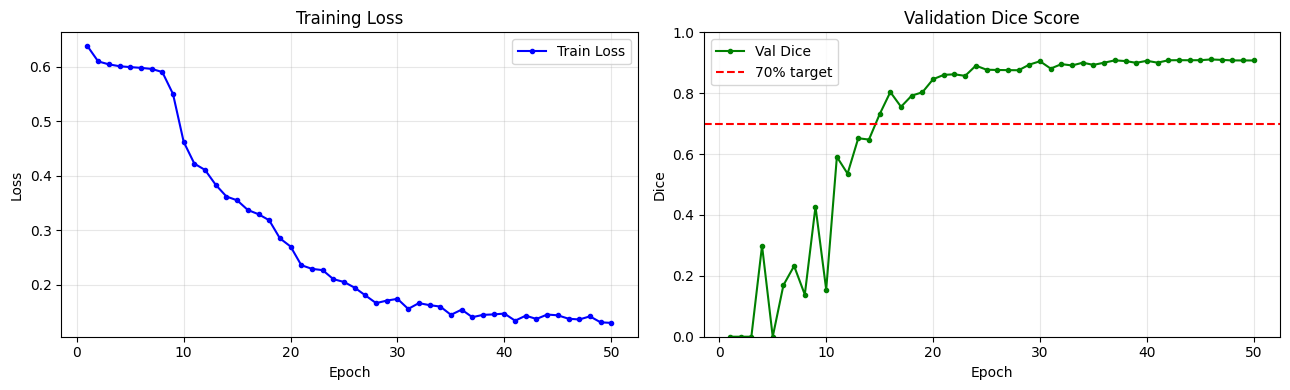

Best Dice: 0.9109


In [9]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['loss'])+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_ran, history['loss'], 'b-o', markersize=3, label='Train Loss')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3); ax1.legend()

ax2.plot(epochs_ran, history['val_dice'], 'g-o', markersize=3, label='Val Dice')
ax2.axhline(0.70, color='red', linestyle='--', label='70% target')
ax2.set_title('Validation Dice Score'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice')
ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout(); plt.show()
print(f'Best Dice: {max(history["val_dice"]):.4f}')

## Cell 9 — Test-time augmentation (TTA) evaluation

In [10]:
def tta_predict(model, imgs, device):
    """Average over 4 flip variants."""
    preds = []
    with torch.no_grad():
        for dims in [None, [-1], [-2], [-1,-2]]:
            x = imgs if dims is None else torch.flip(imgs, dims)
            p = torch.sigmoid(model(x.to(device)))
            preds.append((torch.flip(p, dims) if dims else p).cpu())
    return torch.stack(preds).mean(0)

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

# ── Validation TTA ────────────────────────────────────────────────────────
tta_val_dice = 0.0
for imgs, masks in val_loader:
    probs = tta_predict(model, imgs, device)
    preds = (probs > 0.5).float().view(-1); t = masks.view(-1)
    tta_val_dice += ((2.0*(preds*t).sum()+1e-6)/(preds.sum()+t.sum()+1e-6)).item()
tta_val_dice /= len(val_loader)

# ── Test set evaluation (held-out 20%) ────────────────────────────────────
test_dice     = 0.0
tta_test_dice = 0.0
with torch.no_grad():
    for imgs, masks in test_loader:
        # without TTA
        with autocast():
            logits = model(imgs.to(device))
        test_dice += dice_score(logits, masks.to(device))
        # with TTA
        probs = tta_predict(model, imgs, device)
        preds = (probs > 0.5).float().view(-1); t = masks.view(-1)
        tta_test_dice += ((2.0*(preds*t).sum()+1e-6)/(preds.sum()+t.sum()+1e-6)).item()
test_dice     /= len(test_loader)
tta_test_dice /= len(test_loader)

print('─'*52)
print(f'  Val  Dice  (no TTA) : {best_dice:.4f}  ({best_dice*100:.1f}%)')
print(f'  Val  Dice  (TTA)    : {tta_val_dice:.4f}  ({tta_val_dice*100:.1f}%)')
print('─'*52)
print(f'  Test Dice  (no TTA) : {test_dice:.4f}  ({test_dice*100:.1f}%)')
print(f'  Test Dice  (TTA)    : {tta_test_dice:.4f}  ({tta_test_dice*100:.1f}%)')
print('─'*52)

/tmp/ipykernel_2917/13962314.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


────────────────────────────────────────────────────
  Val  Dice  (no TTA) : 0.9109  (91.1%)
  Val  Dice  (TTA)    : 0.8936  (89.4%)
────────────────────────────────────────────────────
  Test Dice  (no TTA) : 0.9077  (90.8%)
  Test Dice  (TTA)    : 0.8941  (89.4%)
────────────────────────────────────────────────────


## Cell 10 — Save best model back to Google Drive

In [11]:
import shutil

drive_save_path = os.path.join(DRIVE_ROOT, 'best_attunet2d.pth')
shutil.copy(best_path, drive_save_path)
print(f'Model saved to Drive: {drive_save_path}')

Model saved to Drive: /content/drive/MyDrive/Kidney_Stone_Segmentation_2/best_attunet2d.pth


## Cell 11 — Visual predictions on validation & test sets

/tmp/ipykernel_2917/2654690309.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


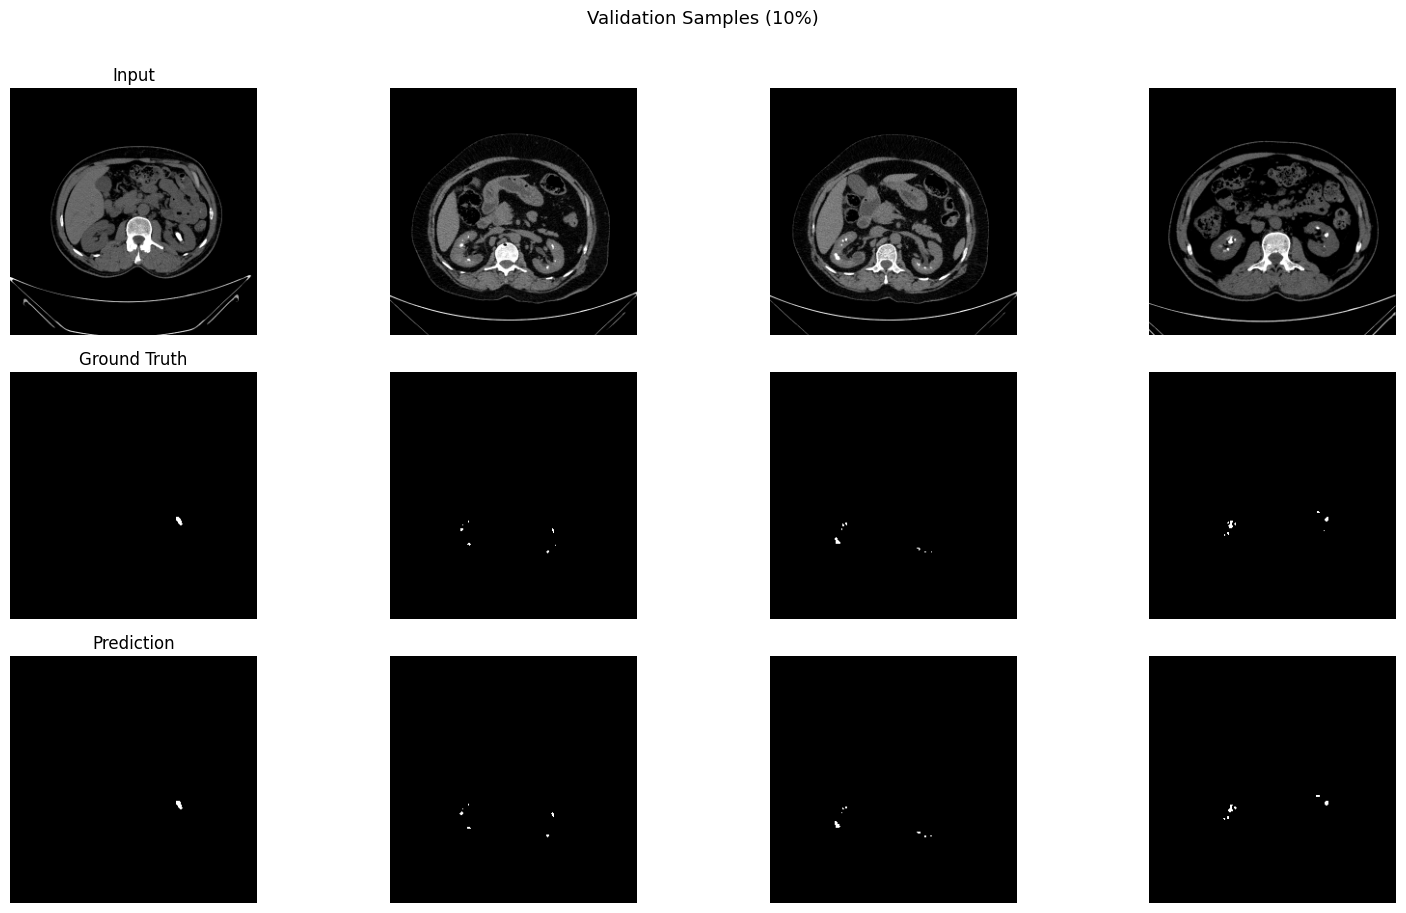

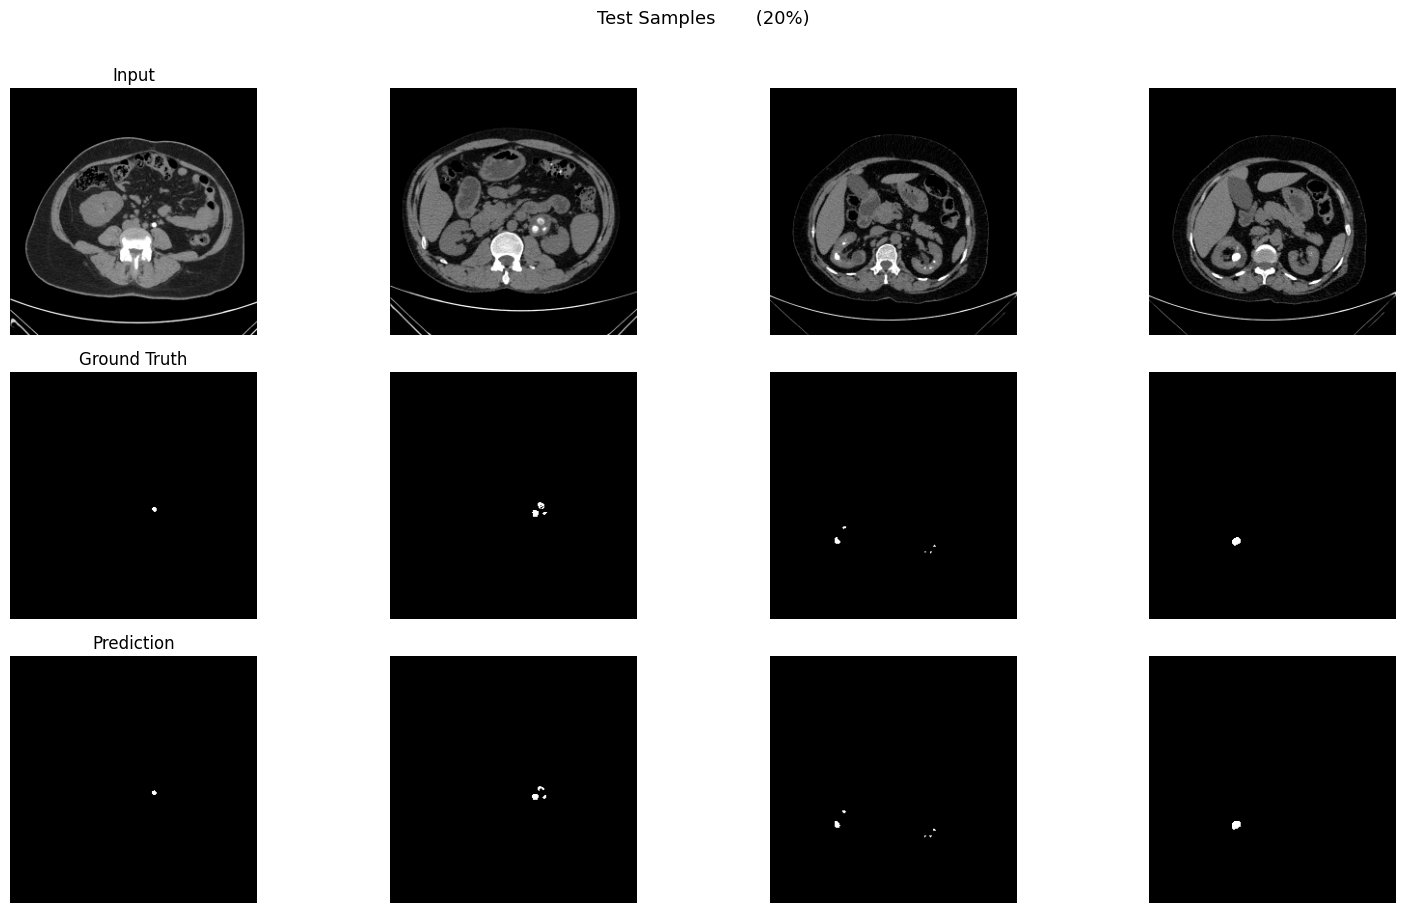

In [12]:
def show_predictions(loader, title, model, device, n=4):
    model.eval()
    imgs, masks = next(iter(loader))
    with torch.no_grad():
        with autocast():
            logits = model(imgs.to(device))
    preds = (torch.sigmoid(logits) > 0.5).float().cpu()
    n = min(n, imgs.shape[0])
    fig, axes = plt.subplots(3, n, figsize=(4*n, 9))
    row_titles = ['Input', 'Ground Truth', 'Prediction']
    for col in range(n):
        for row, (data, rt) in enumerate(zip([imgs[col,0], masks[col,0], preds[col,0]], row_titles)):
            axes[row, col].imshow(data.numpy(), cmap='gray')
            axes[row, col].set_title(rt if col == 0 else '')
            axes[row, col].axis('off')
    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

show_predictions(val_loader,  'Validation Samples (10%)', model, device)
show_predictions(test_loader, 'Test Samples       (20%)', model, device)